# POLARS

## Objetivo del proyecto
El objetivo de este proyecto es realizar un análisis exploratorio de datos utilizando herramientas de Business Intelligence (BI), para extraer información relevante y importante.

se busca transformar datos que no se entiendan casi en información clara estructurada y visualmente comprensible.

## ¿Qué es el Análisis BI?
El Business Intelligence (BI) es el conjunto de procesos, metodologías y herramientas que permiten recopilar, transformar y analizar datos para convertirlos en información útil para la toma de decisiones.

El análisis BI se enfoca en:
Identificar tendencias
Detectar patrones
Medir desempeño
Generar indicadores clave (KPIs)
Apoyar decisiones estratégicas
## Conceptos Estadísticos que se Aplicaran
1. Medidas de tendencia central
2. Medidas de dispersión
3. Distribución de datos
4. Análisis comparativo


"Construimos un sistema de análisis de ventas usando Polars, el cual nos permitió procesar datos eficientemente y aplicar conceptos estadísticos como media, desviación estándar y probabilidad condicional para analizar el comportamiento comercial."

“Se generó un conjunto de datos simulando ventas reales con 100,000 registros para analizar el comportamiento estadístico del sistema.”


### Importar librerías

In [3]:
import polars as pl
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime, timedelta

### Parámetros del modelo

In [4]:
n = 50000  # número de registros

np.random.seed(42)  # para reproducibilidad

### Generación de columnas

In [5]:
# Fechas aleatorias en 2024
start_date = datetime(2024, 1, 1)
dates = [start_date + timedelta(days=int(x)) for x in np.random.randint(0, 365, n)]

# Categorías
categorias = ["Electrónica", "Ropa", "Hogar"]
categoria = np.random.choice(categorias, n)

# Regiones
regiones = ["Norte", "Sur", "Centro", "Oeste"]
region = np.random.choice(regiones, n)

# Precio dependiendo de categoría
precio = []
for cat in categoria:
    if cat == "Electrónica":
        precio.append(np.random.normal(800, 150))
    elif cat == "Ropa":
        precio.append(np.random.normal(120, 30))
    else:
        precio.append(np.random.normal(300, 80))

precio = np.abs(precio)  # evitar negativos

# Cantidad
cantidad = np.random.randint(1, 10, n)

### Crear DataFrame con Polars

In [28]:
df = pl.DataFrame({
    "fecha": dates,
    "categoria": categoria,
    "region": region,
    "precio": precio,
    "cantidad": cantidad
})

df = df.with_columns(
    (pl.col("precio") * pl.col("cantidad")).alias("ingreso")
)

df.head()

fecha,categoria,region,precio,cantidad,ingreso
datetime[μs],str,str,f64,i32,f64
2024-04-12 00:00:00,"""Electrónica""","""Norte""",626.63892,8,5013.111359
2024-12-14 00:00:00,"""Hogar""","""Sur""",256.805761,2,513.611521
2024-09-27 00:00:00,"""Ropa""","""Oeste""",112.215276,8,897.722205
2024-04-16 00:00:00,"""Ropa""","""Oeste""",126.484993,4,505.939972
2024-03-12 00:00:00,"""Ropa""","""Sur""",119.489038,9,1075.401338


## Estadística Descriptiva General
### Estadísticos principales

La media representa el ingreso promedio por venta.
La mediana nos indica el valor central de la distribución.
La varianza y desviación estándar miden la dispersión de los ingresos respecto a la media.
Si la desviación estándar es alta, significa que las ventas son muy variables.

In [8]:
resumen_general = df.select([
    pl.col("ingreso").mean().alias("Media"),
    pl.col("ingreso").median().alias("Mediana"),
    pl.col("ingreso").var().alias("Varianza"),
    pl.col("ingreso").std().alias("Desviación Estándar"),
    pl.col("ingreso").min().alias("Mínimo"),
    pl.col("ingreso").max().alias("Máximo")
])

resumen_general

Media,Mediana,Varianza,Desviación Estándar,Mínimo,Máximo
f64,f64,f64,f64,f64,f64
2034.851773,1222.313006,4.0444e6,2011.072987,32.320099,11116.316243


### Cuartiles y Percentiles

Esto muestra cómo se distribuyen los datos:

El 25% de las ventas están por debajo de Q1.
El 50% están por debajo de la mediana.
El 75% están por debajo de Q3.
Esto nos permite analizar la concentración de ingresos

In [9]:
cuartiles = df.select([
    pl.col("ingreso").quantile(0.25).alias("Q1"),
    pl.col("ingreso").quantile(0.50).alias("Q2 (Mediana)"),
    pl.col("ingreso").quantile(0.75).alias("Q3")
])

cuartiles

Q1,Q2 (Mediana),Q3
f64,f64,f64
614.344277,1222.321267,2780.885038


### Análisis por Región
Se utiliza estadística condicional


Este análisis nos permite comparar el comportamiento estadístico de las ventas entre regiones.
Si una región tiene mayor media pero también mayor desviación, implica mayor riesgo y variabilidad.

In [10]:
analisis_region = df.group_by("region").agg([
    pl.col("ingreso").mean().alias("Ingreso Promedio"),
    pl.col("ingreso").std().alias("Desviación"),
    pl.col("ingreso").count().alias("Número de Ventas")
])

analisis_region

region,Ingreso Promedio,Desviación,Número de Ventas
str,f64,f64,u32
"""Sur""",2040.351925,2031.485395,12497
"""Norte""",2043.370455,2019.382714,12541
"""Centro""",2012.01476,1977.345519,12516
"""Oeste""",2043.710834,2015.77646,12446


### Probabilidad Empirica

Queremos calcular:

𝑃( Venta en Norte) P(Venta en Norte)

La probabilidad empírica se calcula como:
P(A)= numero de casos favorables/ numero total de casos

Aquí estamos estimando la probabilidad de que una venta ocurra en determinada región.

In [11]:
total_ventas = df.height

probabilidad_region = df.group_by("region").count().with_columns(
    (pl.col("count") / total_ventas).alias("Probabilidad Empírica")
)

probabilidad_region

C:\Users\Usuario\AppData\Local\Temp\ipykernel_16476\2382215862.py:3: DeprecationWarning: `GroupBy.count` was renamed; use `GroupBy.len` instead
  probabilidad_region = df.group_by("region").count().with_columns(


region,count,Probabilidad Empírica
str,u32,f64
"""Centro""",12516,0.25032
"""Norte""",12541,0.25082
"""Oeste""",12446,0.24892
"""Sur""",12497,0.24994


### Probabilidad Condicional

La probabilidad condicional se define como:

p(A|B)= P(A ∩ B) / P(B)

En este caso calculamos la probabilidad de que una venta sea de Electrnica dado que ocurrioen la región Norte.

In [12]:
ventas_norte = df.filter(pl.col("region") == "Norte").height

electronica_norte = df.filter(
    (pl.col("region") == "Norte") &
    (pl.col("categoria") == "Electrónica")
).height

prob_condicional = electronica_norte / ventas_norte

prob_condicional

0.3397655689338968

### 1.visualizacion o histograma
El histograma nos permite observar la forma de la distribución:
si es simétrica, sesgada o presenta valores extremos.

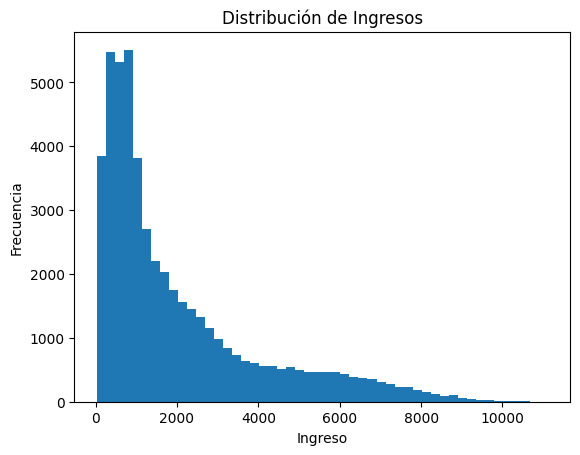

In [13]:
plt.hist(df["ingreso"].to_numpy(), bins=50)
plt.title("Distribución de Ingresos")
plt.xlabel("Ingreso")
plt.ylabel("Frecuencia")
plt.show()

### ANÁLISIS TEMPORAL (Ventas por mes)

In [14]:
df = df.with_columns(
    pl.col("fecha").dt.month().alias("mes")
)

ventas_mensuales = df.group_by("mes").agg(
    pl.col("ingreso").sum().alias("Ingreso Total")
).sort("mes")

ventas_mensuales

mes,Ingreso Total
i8,f64
1,8.8389e6
2,8.2377e6
3,8.7081e6
4,8.6532e6
5,8.5096e6
…,…
8,8.6639e6
9,8.3331e6
10,8.5209e6


#### Gráfica

El anaisis temporal permite observar la evolución del ingreso a lo largo del año.
Se puede identificar estacionalidad o meses con mayor actividad económica.

Si hay meses pico → posible alta demanda.
Si hay meses bajos → posible temporada baja.

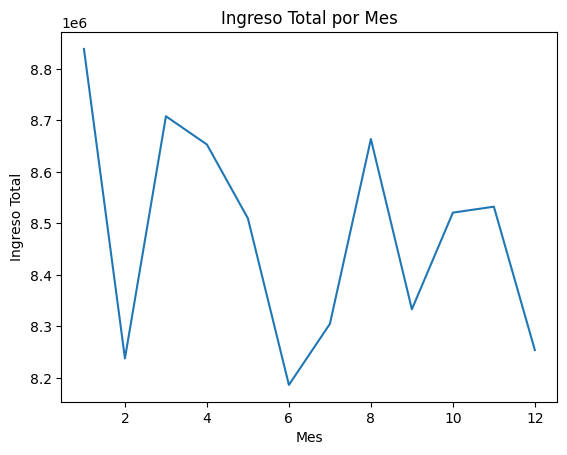

In [15]:
plt.plot(ventas_mensuales["mes"].to_numpy(),
         ventas_mensuales["Ingreso Total"].to_numpy())

plt.title("Ingreso Total por Mes")
plt.xlabel("Mes")
plt.ylabel("Ingreso Total")
plt.show()

### 3. DETECCION DE OUTLIERS (IQR )

In [16]:
Q1 = df.select(pl.col("ingreso").quantile(0.25)).item()
Q3 = df.select(pl.col("ingreso").quantile(0.75)).item()

IQR = Q3 - Q1

limite_inferior = Q1 - 1.5 * IQR
limite_superior = Q3 + 1.5 * IQR

outliers = df.filter(
    (pl.col("ingreso") < limite_inferior) |
    (pl.col("ingreso") > limite_superior)
)

outliers.height

3472

Los valores atipicos representan ventas inusualmente bajas o altas.
Estos pueden deberse a promociones especiales o errores en los datos.

### 4. ANALISIS DE DISPERSION POR CATEGORIA

In [17]:
analisis_categoria = df.group_by("categoria").agg([
    pl.col("ingreso").mean().alias("Media"),
    pl.col("ingreso").std().alias("Desviación")
])

analisis_categoria

categoria,Media,Desviación
str,f64,f64
"""Ropa""",600.28236,354.654746
"""Electrónica""",3993.34128,2230.03195
"""Hogar""",1496.242066,889.669137


Si una categoría tiene alta media pero también alta desviación,
implica mayores ingresos pero mayor riesgo financiero.

## Conclusiones

1. A partir del análisis estadístico realizado sobre 50,000 registros simulados de ventas, se obtuvo una vision  del comportamiento comercial del sistema.

2. La media y mediana mostraron el nivel tipico de ingresos por venta, mientras que la desviacion estándar permitio evaluar la dispersion y estabilidad financiera.

3. El análisis por región evidencio diferencias significativas en el ingreso promedio, indicando posibles variaciones en demanda o poder adquisitivo.

4. La probabilidad empírica permitio estimar la frecuencia relativa de eventos comerciales, mientras que la probabilidad condicional ayudo a analizar relaciones entre region y categoría.

5. El analisis temporal muestra variaciones mensuales que podrian interpretarse como estacionalidad.

6. la detección de valores  permitio identificar ventas extraordinarias que podrian representar oportunidades o riesgos.

7. El uso de Polars permitio manejar eficientemente un volumen considerable de datos, demostrando su utilidad en analisis estadístico aplicado a escenarios empresariales y su velocidad gracias a Rust.
